**Heston model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from utils import non_uniform_grid, set_matplotlib_style
from data import get_params, DATES
from heston import HestonModel

set_matplotlib_style()
SEED = 1234
SAVEFIG = False

# SSR Expansions

## Market data (Figure 4)

In [3]:
# parameters
date = DATES[1]
print(f"Using parameters from {date}")
# model
heston = HestonModel(get_params(date=date, model="heston"))
heston

Using parameters from 2024-08-05


HestonModel with parameters:
v=0.117, kappa=3.37, vbar=0.048, eta=1.99, rho=-0.68, s0=1.0

In [4]:
# compute true beta, atm skew and SSRs
Ts = non_uniform_grid(a=7.0 / 365.0, b=3.0, n=15, power=1.5)
out = heston.ssr_all(Ts, eps=1e-3)

In [5]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 3, 200)
out_bg = heston.ssr_bg_all(Ts_bg)

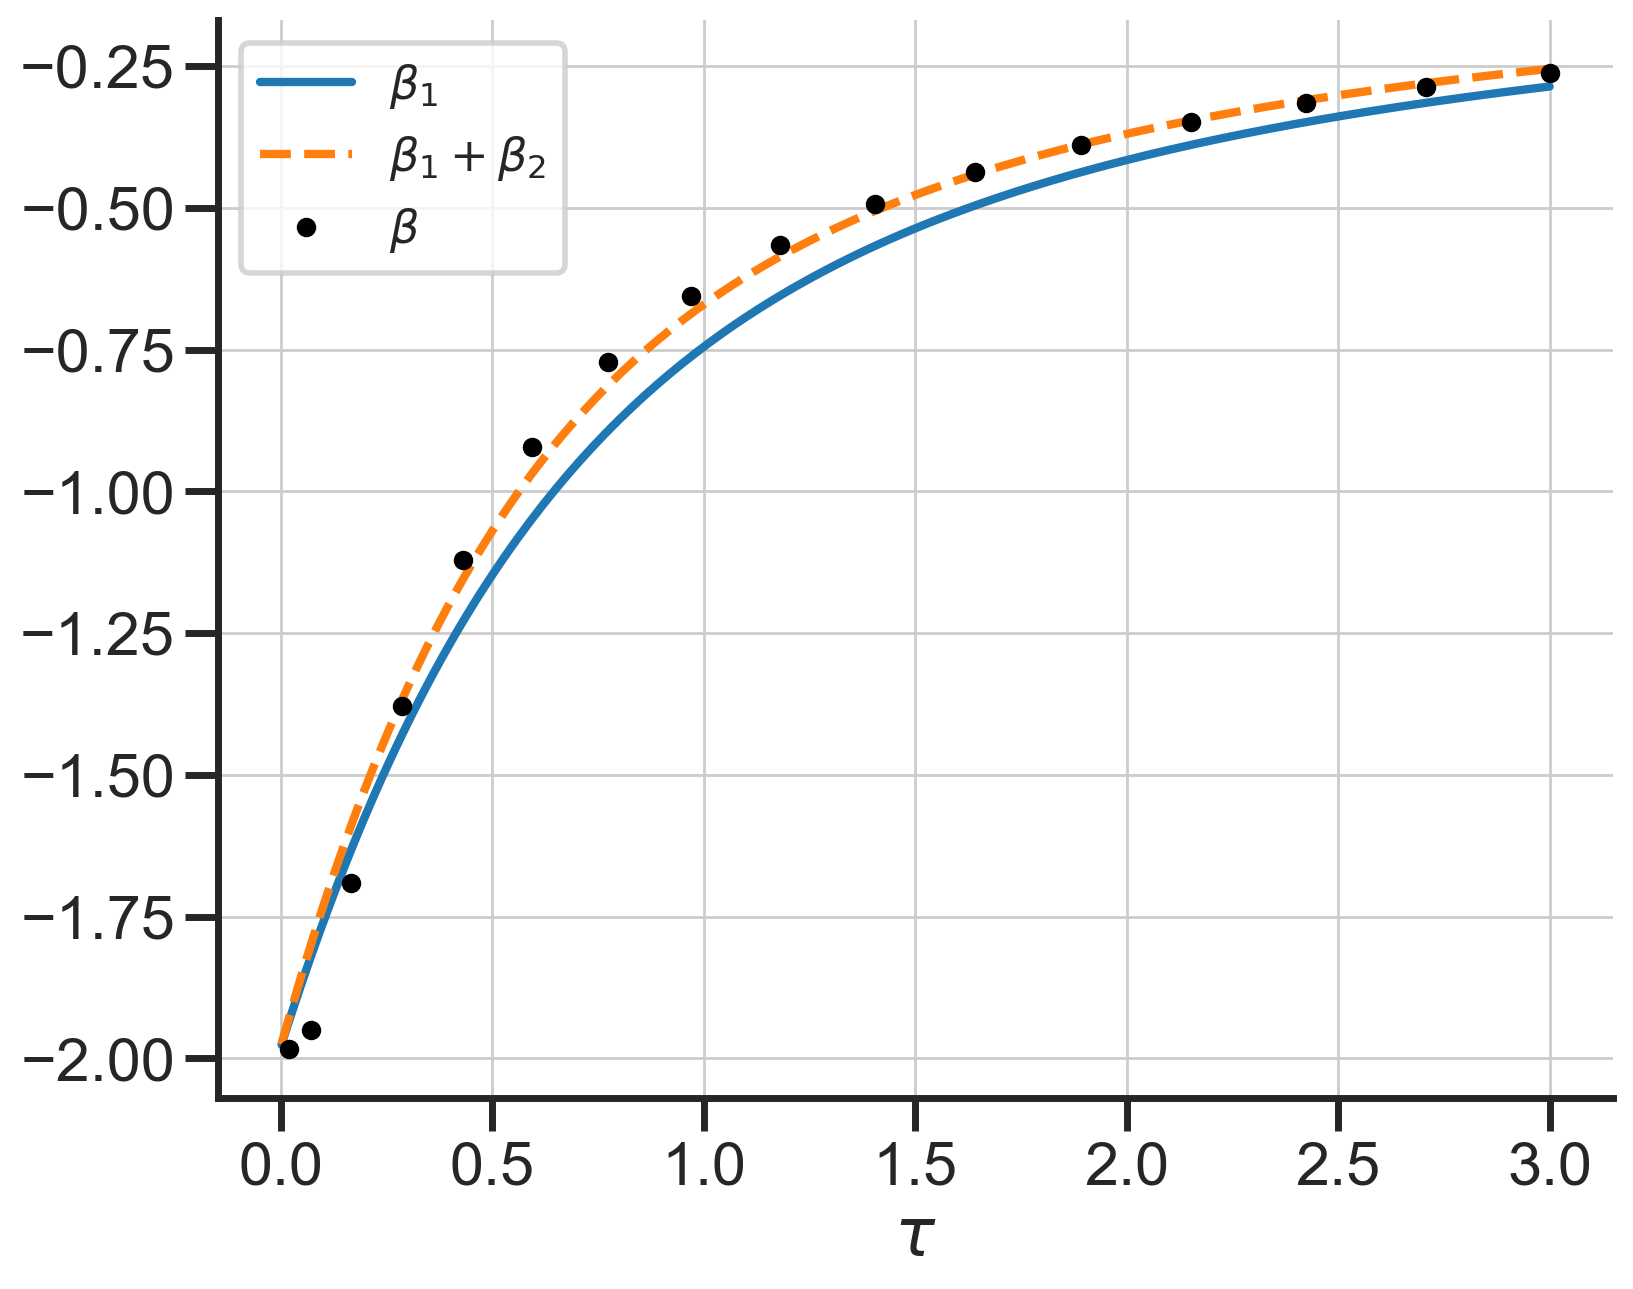

In [6]:
# plot beta
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["beta_1"], "-", label=r"$\beta_1$")
ax.plot(Ts_bg, out_bg["beta_1"] + out_bg["beta_2"], "--", label=r"$\beta_1+\beta_2$")
ax.plot(Ts, out["beta"], ".k", label=r"$\beta$")
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/heston/heston_{date}_beta.pdf", bbox_inches="tight")
plt.show()

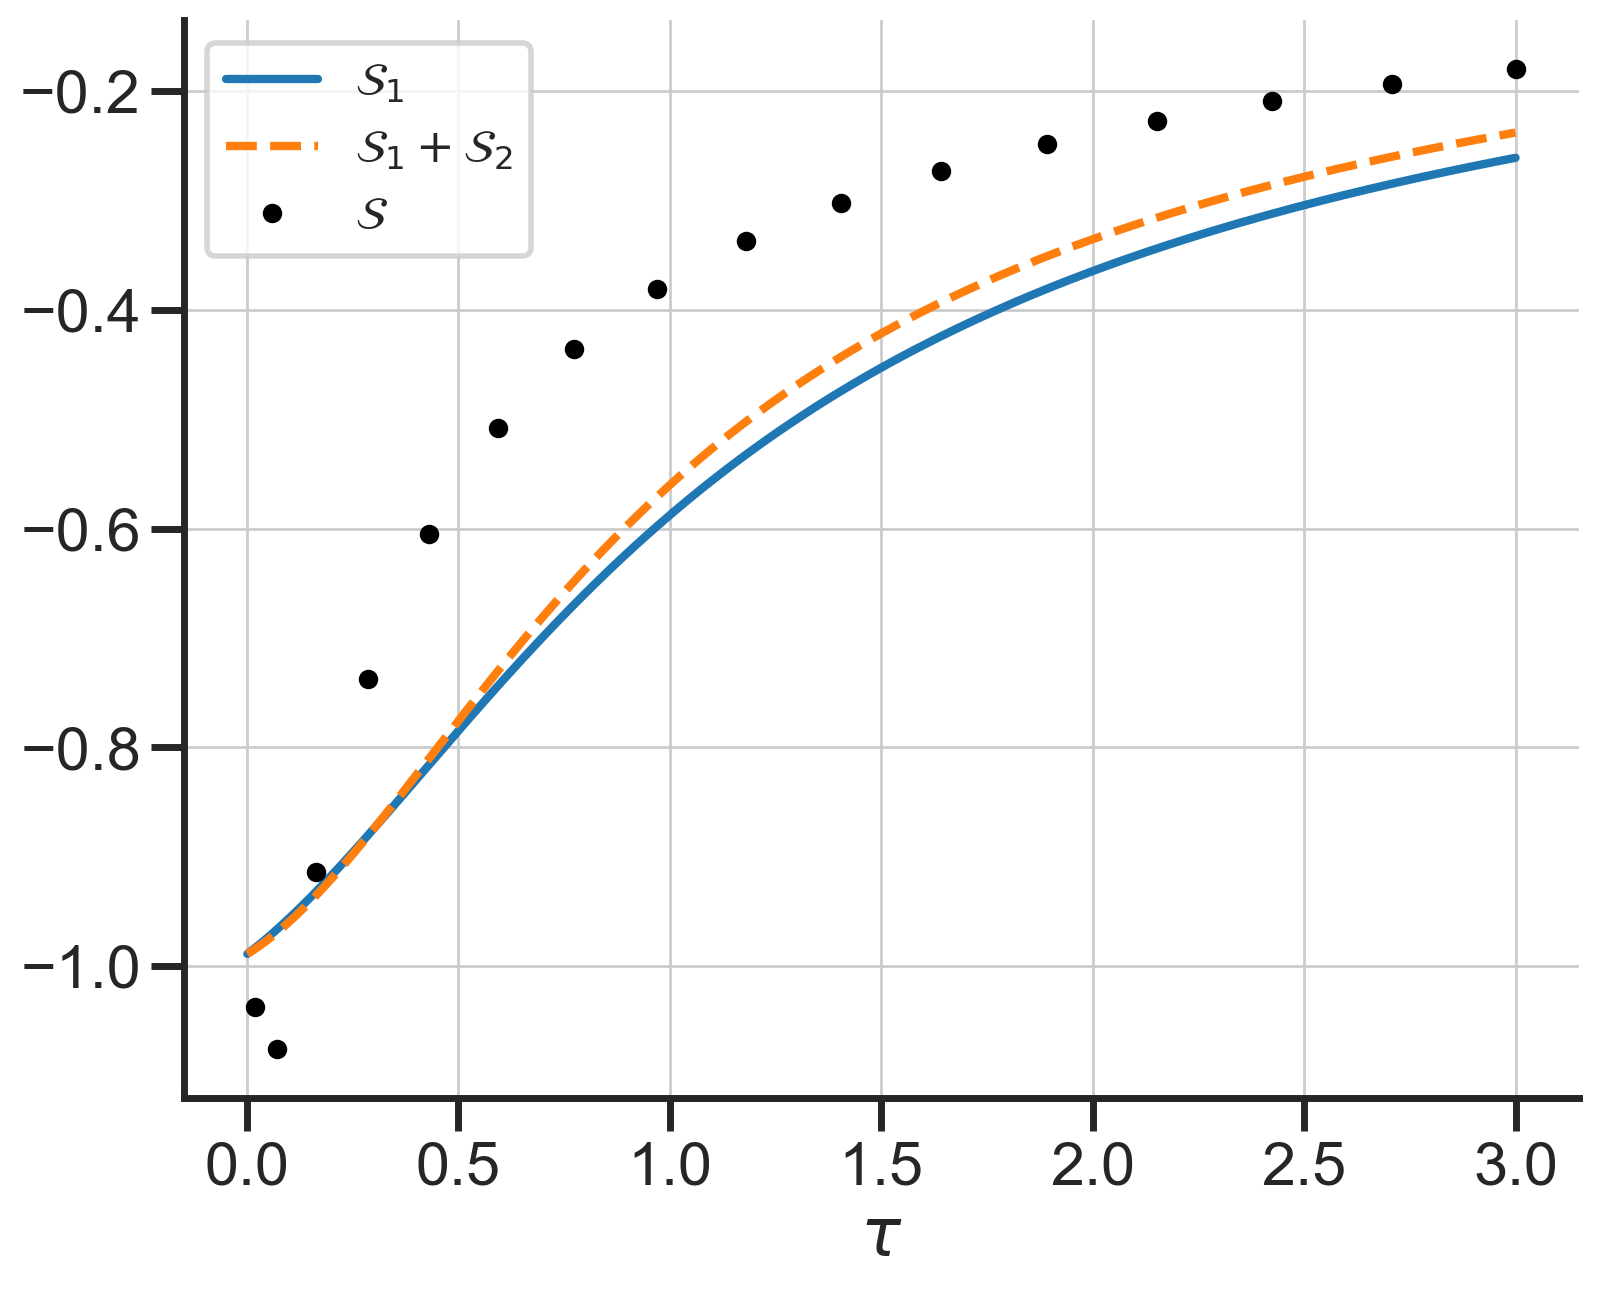

In [7]:
# plot ATM skew
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["atm_skew_1"], "-", label=r"$\mathcal{S}_1$")
ax.plot(
    Ts_bg,
    out_bg["atm_skew_1"] + out_bg["atm_skew_2"],
    "--",
    label=r"$\mathcal{S}_1+\mathcal{S}_2$",
)
ax.plot(Ts, out["atm_skew"], ".k", label=r"$\mathcal{S}$")
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/heston/heston_{date}_atm_skew.pdf", bbox_inches="tight")
plt.show()

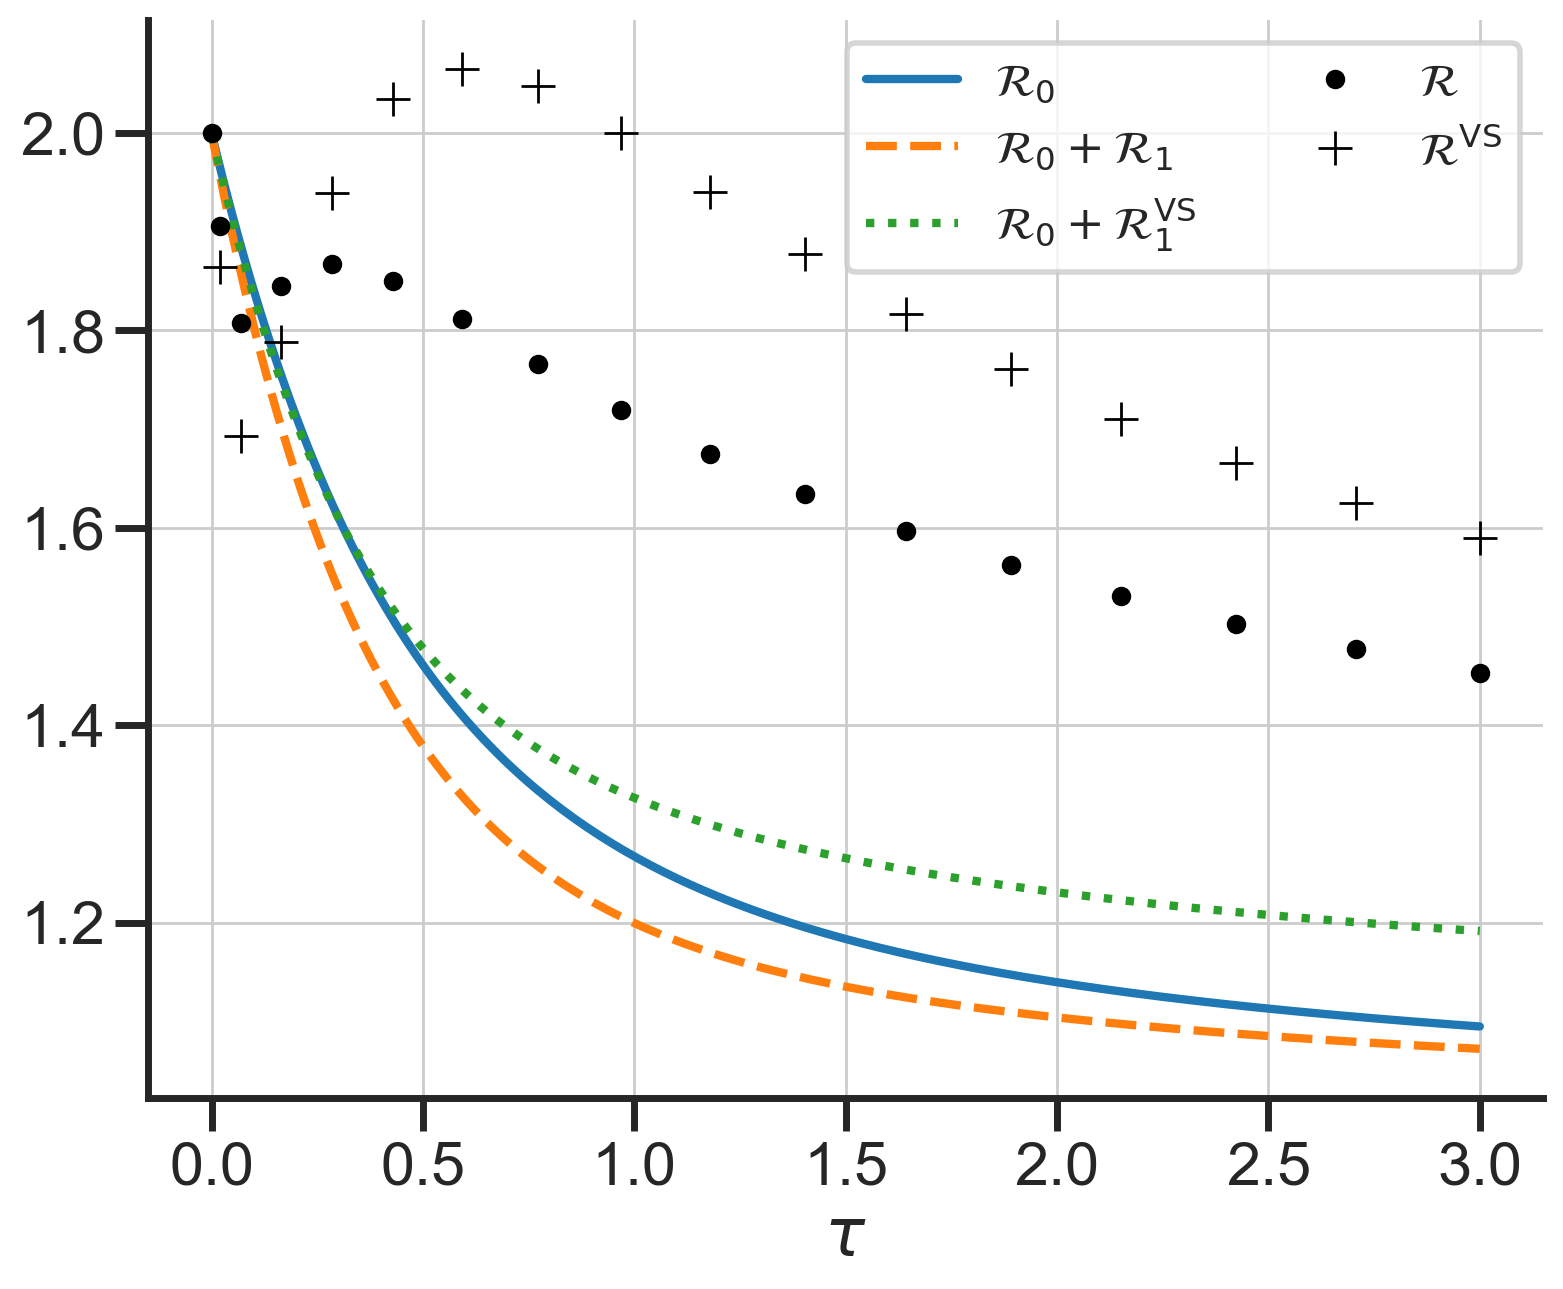

In [8]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_cf"], ".k", label=r"$\mathcal{R}$")
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.plot([0], [2], ".k")
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/heston/heston_{date}_ssr.pdf", bbox_inches="tight")
plt.show()

### Hybrid formula

In [9]:
# using same maturities for SSRs
out_bg = heston.ssr_bg_all(Ts)

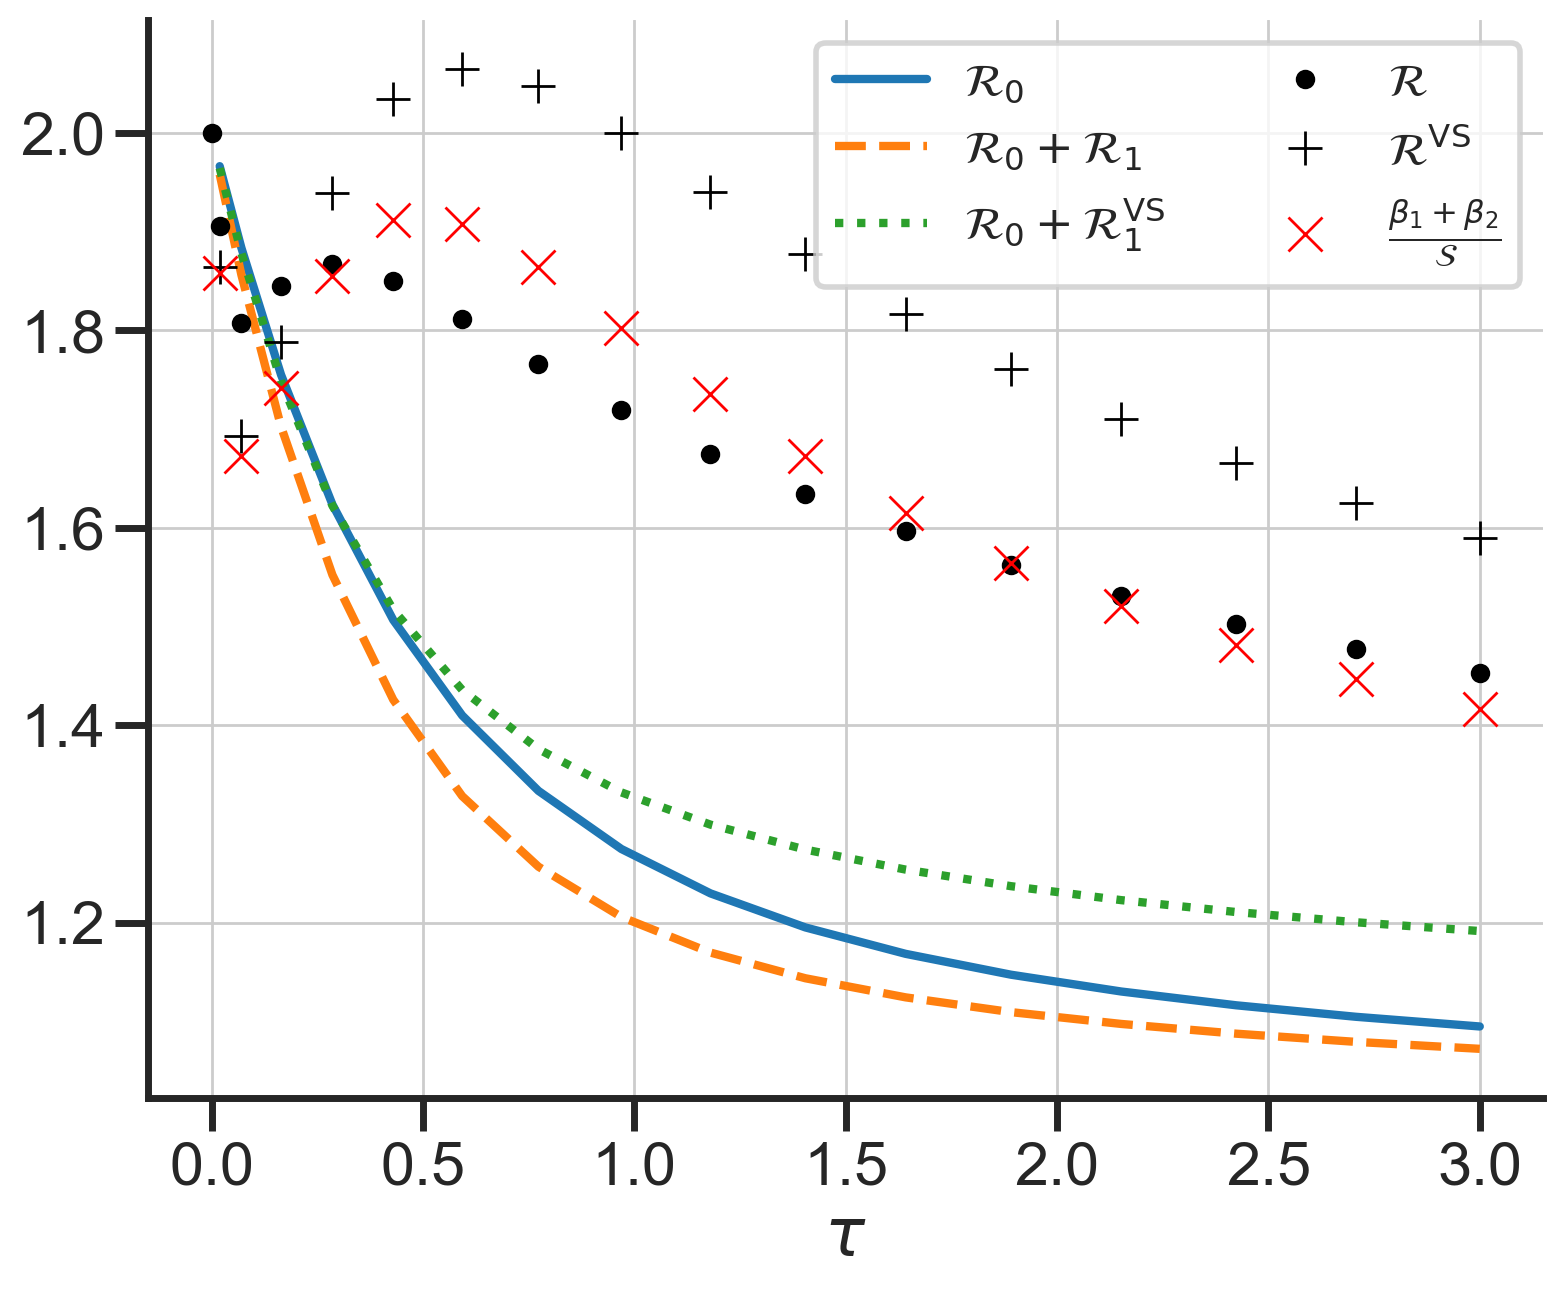

In [10]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_cf"], ".k", label=r"$\mathcal{R}$")
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
# hybrid formula
ax.plot(
    Ts,
    (out_bg["beta_1"] + out_bg["beta_2"]) / out["atm_skew"],
    "rx",
    label=r"$\frac{\beta_1+\beta_2}{\mathcal{S}}$",
)
ax.plot([0], [2], ".k")
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/heston/heston_{date}_ssr_hybrid.pdf", bbox_inches="tight")
plt.show()

# Signed between ATMF and VS SSR

In [11]:
from heston import get_params_heston

In [12]:
get_params_heston(1)

{'kappa': 1.0, 'rho': -0.8, 'eta': 0.6, 'vbar': 0.04, 'v': 0.04}

In [13]:
# date = DATES[0]
# print(f"Using parameters from {date}")
# params = get_params(date=date, model="heston")
id = 1
params = get_params_heston(1)

In [14]:
Ts = np.array([0.1, 0.5, 1.0, 3.0])
rhos = np.linspace(-0.9, 0.9, 20)
diff_vs_atmf_ssr = np.zeros((len(Ts), len(rhos)))
diff_vs_atmf_ssr_bg = np.zeros((len(Ts), len(rhos)))

for i, rho in enumerate(rhos):
    params["rho"] = rho
    heston = HestonModel(params)
    out = heston.ssr_all(Ts, eps=1e-3)
    diff_vs_atmf_ssr[:, i] = out["ssr_vs"] - out["ssr_cf"]

    out = heston.ssr_bg_all(Ts)
    diff_vs_atmf_ssr_bg[:, i] = out["ssr_vs_1"] - out["ssr_1"]

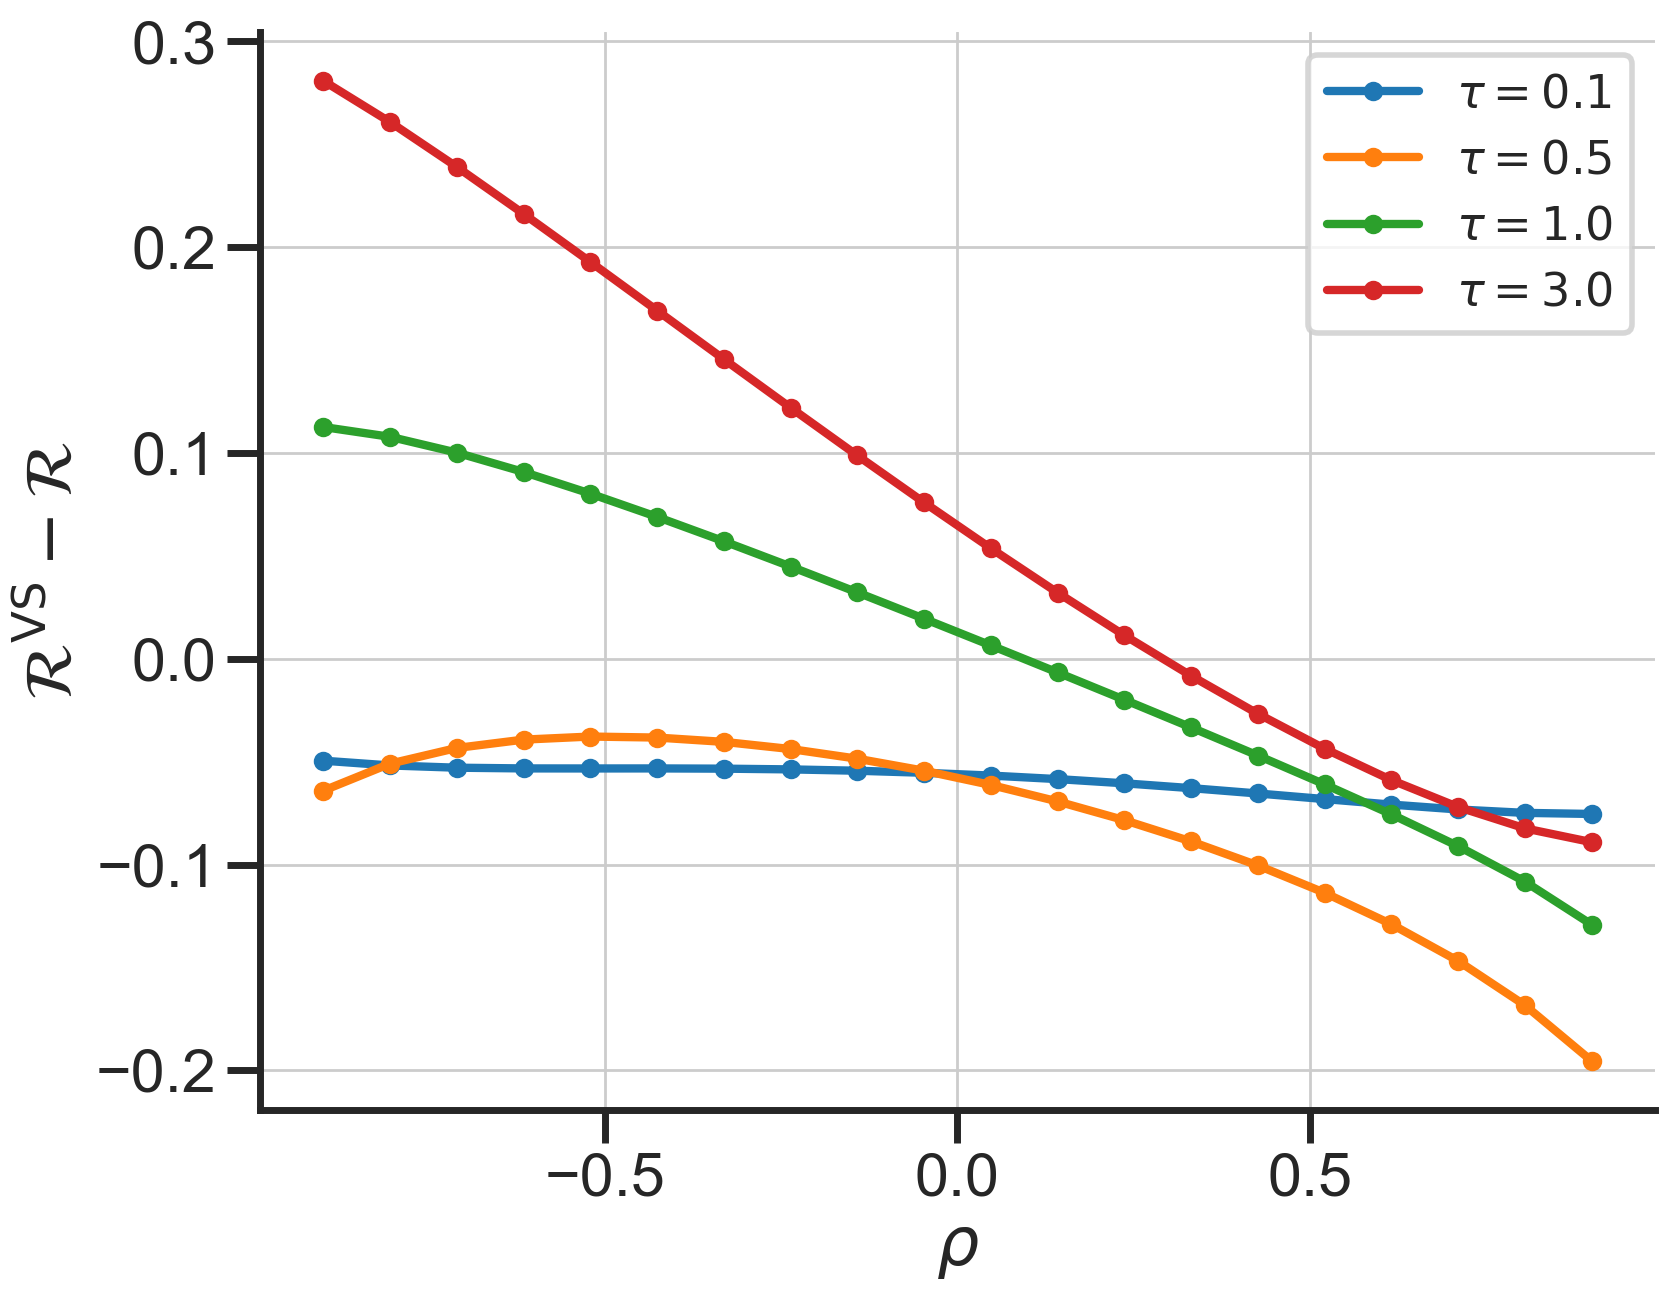

In [15]:
# difference between VS SSR and true SSR for different values of rho
fig, ax = plt.subplots()
for i, T in enumerate(Ts):
    ax.plot(rhos, diff_vs_atmf_ssr[i, :], ".-", label=f"$\\tau={T}$")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\mathcal{R}^{\text{VS}} - \mathcal{R}$")
ax.legend()
if SAVEFIG:
    fig.savefig(
        f"figures/heston/heston_set_{id}_diff_vs_atmf_ssr.pdf", bbox_inches="tight"
    )
plt.show()

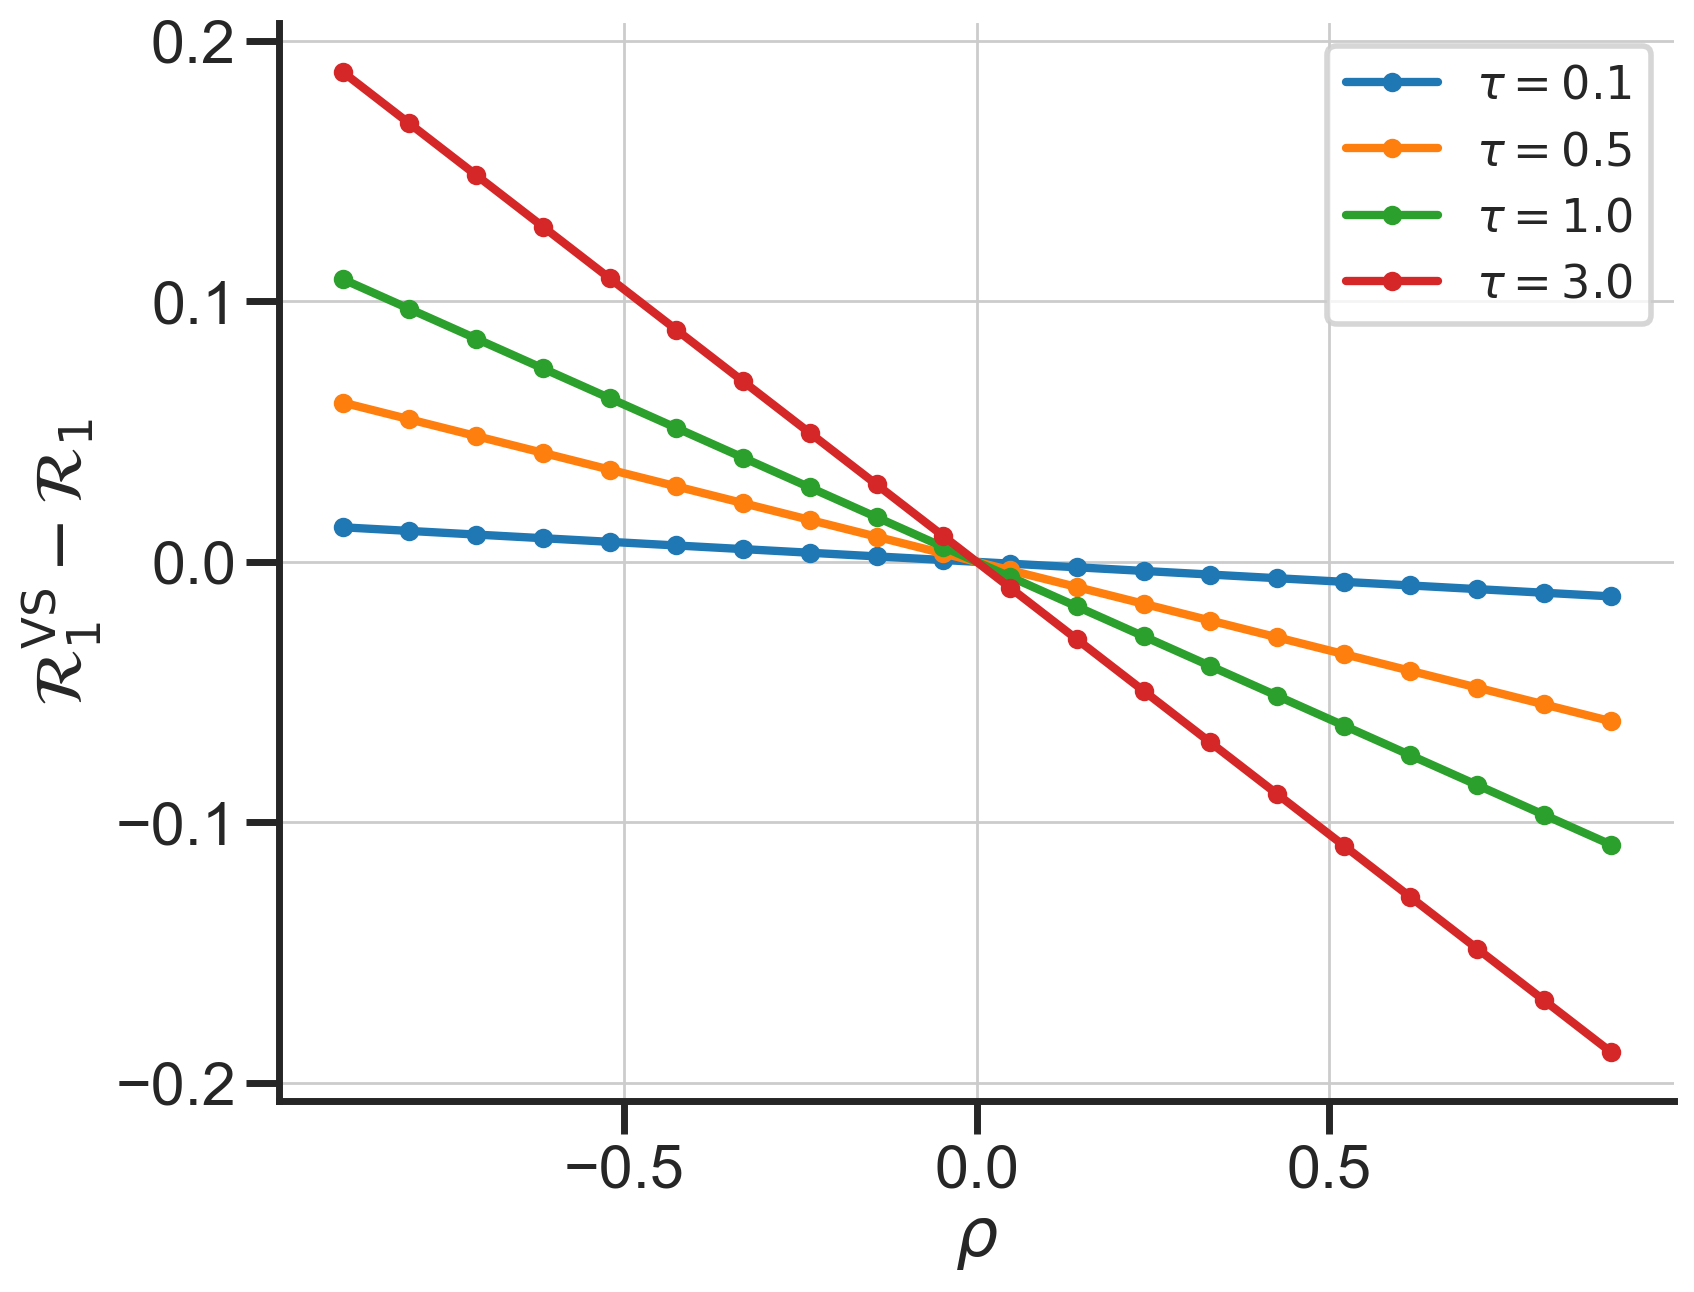

In [16]:
# difference between VS SSR and SSR (BG expansion) for different values of rhos
fig, ax = plt.subplots()
for i, T in enumerate(Ts):
    ax.plot(rhos, diff_vs_atmf_ssr_bg[i, :], ".-", label=f"$\\tau={T}$")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\mathcal{R}_1^{\text{VS}} - \mathcal{R}_1$")
ax.legend()
if SAVEFIG:
    fig.savefig(
        f"figures/heston/heston_set_{id}_diff_vs_atmf_ssr_bg.pdf", bbox_inches="tight"
    )
plt.show()

# 2D error surface of the BG expansion

We compute the error of the BG expansion for a grid of values of 
of some of the parameters of the Heston model, and plot the error surface.

In [17]:
date = DATES[0]
print(f"Using parameters from {date}")
params_date = get_params(date=date, model="heston")
params_date

Using parameters from 2024-05-06


{'v': 0.011, 'kappa': 1.1, 'vbar': 0.043, 'eta': 0.24, 'rho': -1.0}

## kappa-eta

In [18]:
# kappa-eta error surface

# fix maturities
Ts = [0.1, 0.5, 1.0]

# grid parameters
nx = 50
ny = 50
xs = np.linspace(0.1, 3, nx)
ys = np.linspace(0.1, 2, ny)
sgn_rel_err = np.zeros((len(Ts), len(xs), len(ys)))

for i, kappa in enumerate(xs):
    print(f"{i + 1}/{len(xs)}", end="\r", flush=True)
    for j, eta in enumerate(ys):
        params_i_j = {
            "kappa": kappa,
            "eta": eta,
            "v": params["v"],
            "rho": params["rho"],
            "vbar": params["vbar"],
        }
        heston = HestonModel(params_i_j)
        ssr_cf = heston.ssr_cf(Ts)
        out_bg = heston.ssr_bg_all(Ts)
        ssr_expansion = out_bg["ssr_0"] + out_bg["ssr_1"]
        sgn_rel_err[:, i, j] = (ssr_expansion - ssr_cf) / ssr_cf

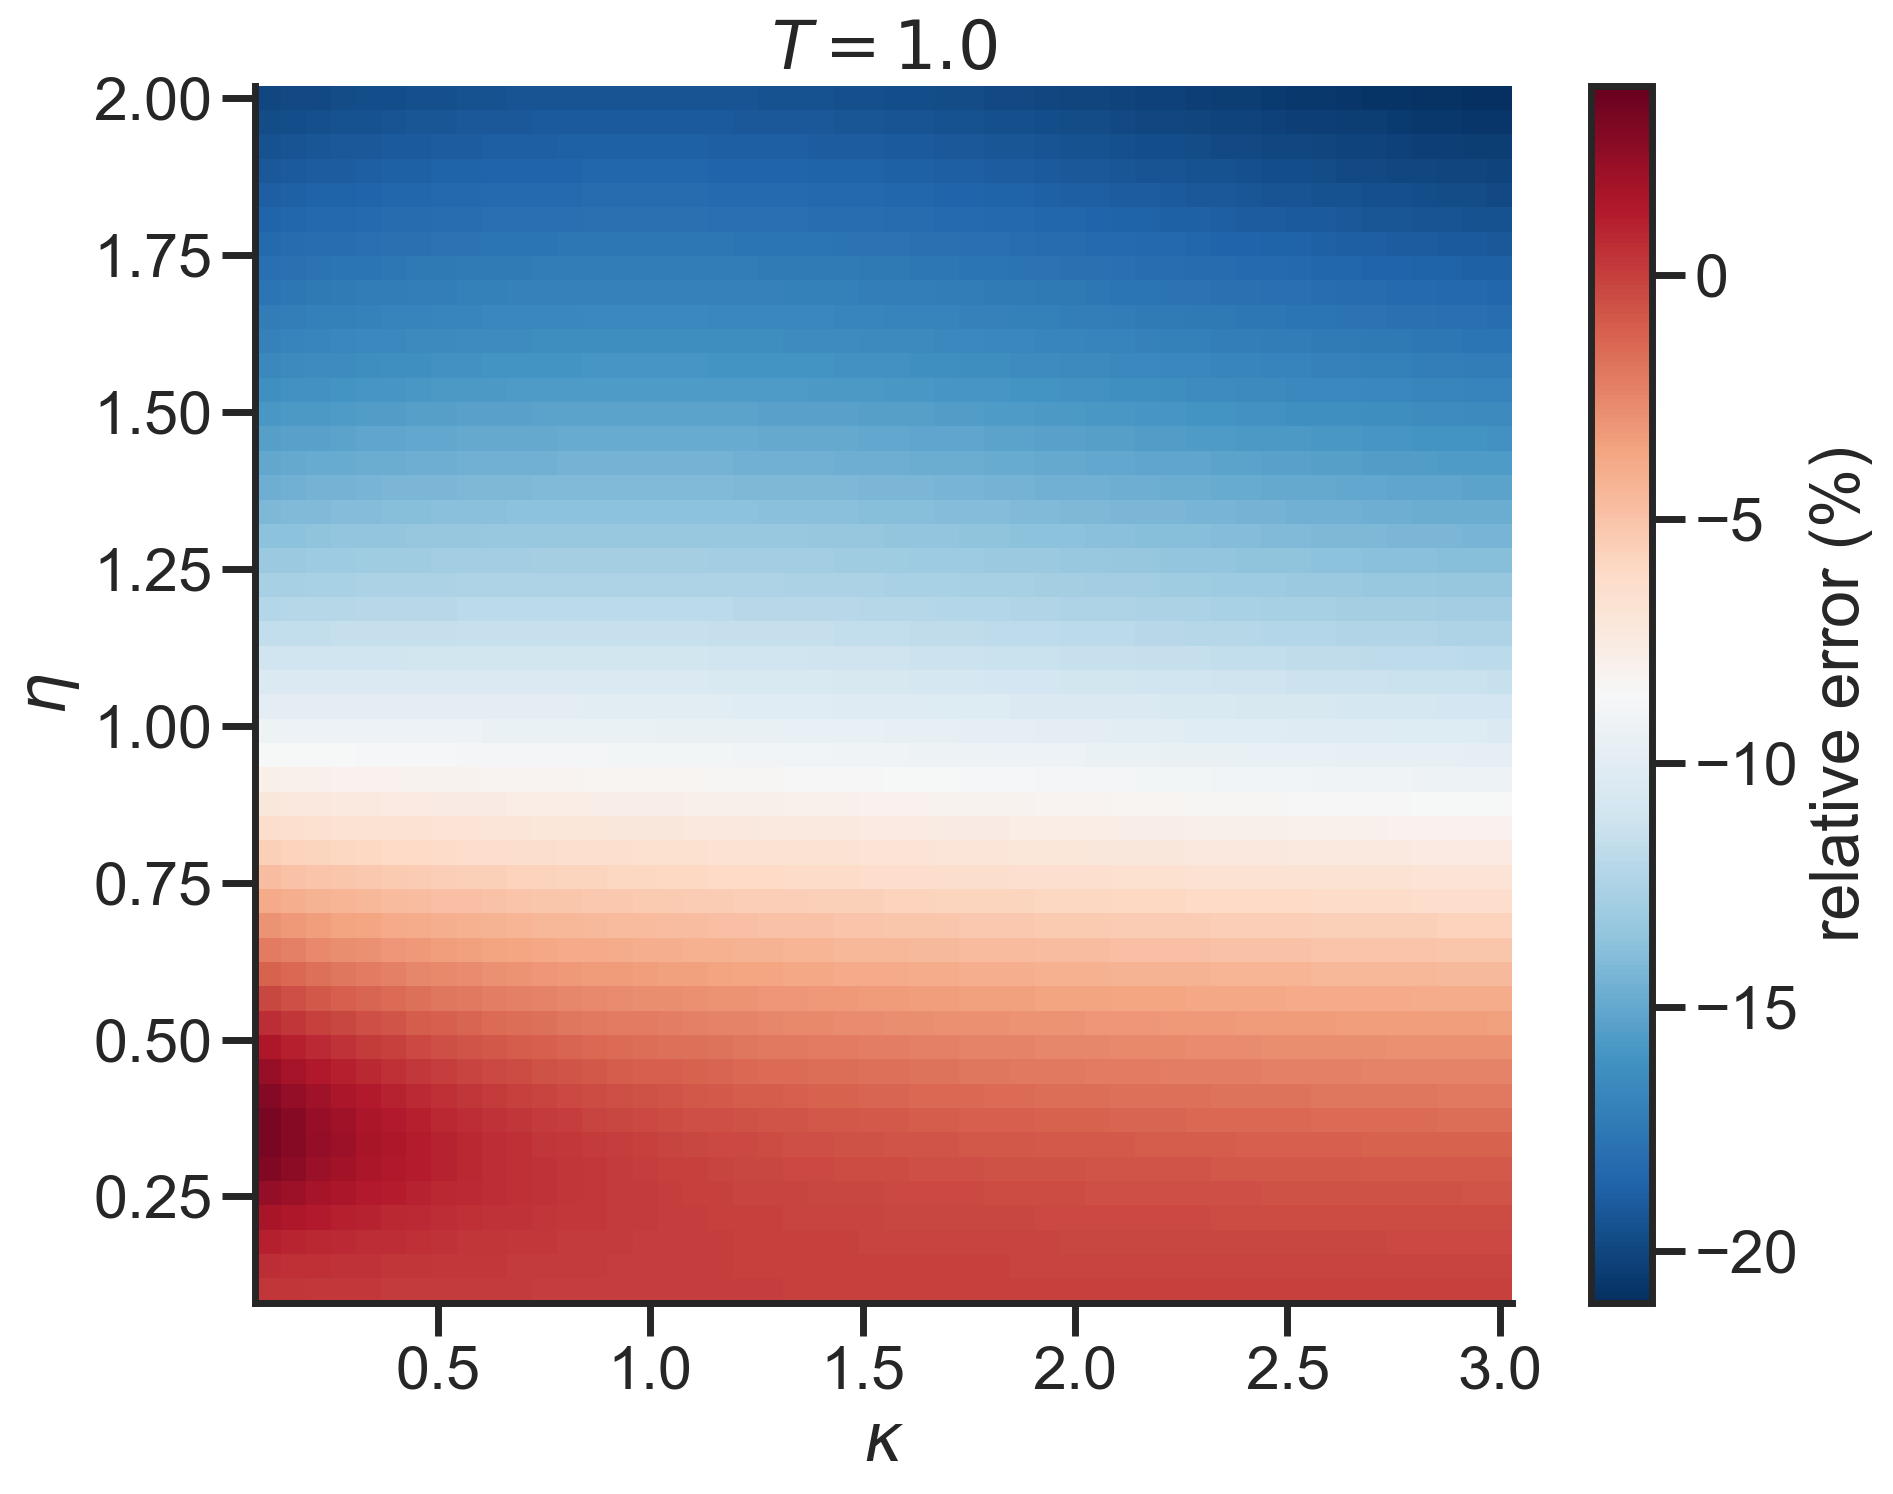

In [19]:
x_grid, y_grid = np.meshgrid(xs, ys, indexing="ij")

vmin = 100 * np.min(sgn_rel_err)
vmax = 100 * np.max(sgn_rel_err)
idx_T = 2  # pick maturity

fig, ax = plt.subplots(figsize=(10, 8))
pcm = ax.pcolormesh(
    x_grid,
    y_grid,
    100 * sgn_rel_err[idx_T, :, :],
    shading="auto",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
)
fig.colorbar(pcm, ax=ax, label="relative error (%)")
ax.set_xlabel(r"$\kappa$")
ax.set_ylabel(r"$\eta$")
ax.set_title(f"$T={Ts[idx_T]}$")
plt.tight_layout()
if SAVEFIG:
    fig.savefig(
        f"figures/heston/heston_{date}_ssr_rel_error_T_{Ts[idx_T]}.pdf",
        bbox_inches="tight",
    )
plt.show()

# Sensitivity to finite difference parameter

In [20]:
# parameters
date = DATES[1]
print(f"Using parameters from {date}")
# model
heston = HestonModel(get_params(date=date, model="heston"))
heston

Using parameters from 2024-08-05


HestonModel with parameters:
v=0.117, kappa=3.37, vbar=0.048, eta=1.99, rho=-0.68, s0=1.0

In [21]:
arr_eps = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
Ts = np.linspace(1e-3, 3, 20)

arr_ssr_fd = np.array([heston.ssr_fd(Ts, eps=eps) for eps in arr_eps])
ssr_cf = heston.ssr_cf(Ts)
rel_error = (arr_ssr_fd - ssr_cf) / ssr_cf

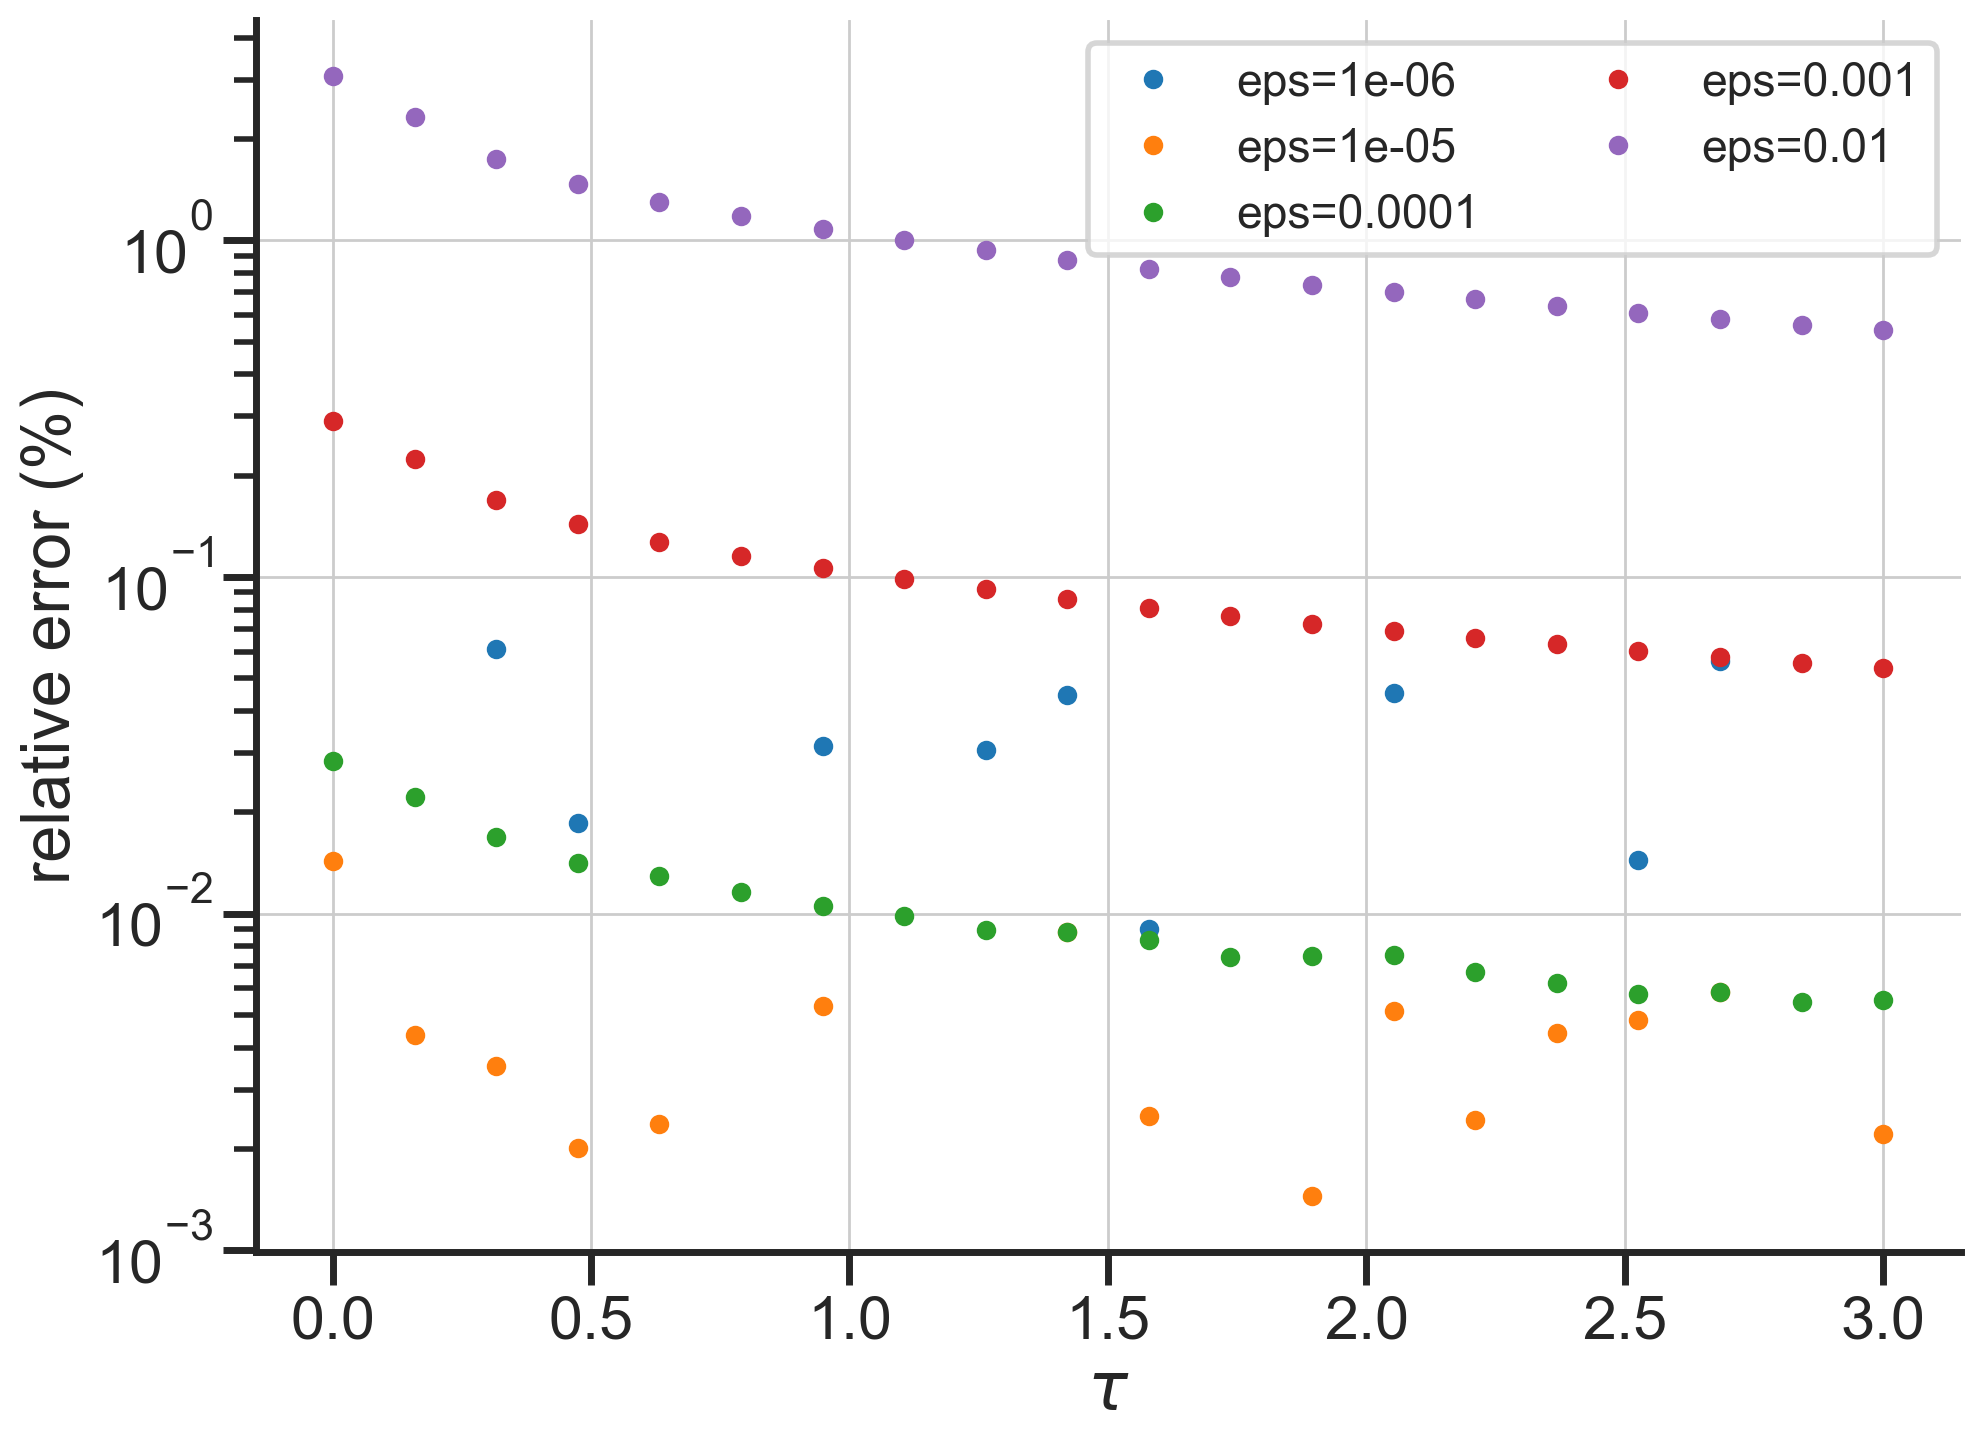

In [23]:
fig, ax = plt.subplots(figsize=(11, 8))
for i, eps in enumerate(arr_eps):
    ax.plot(Ts, 100 * rel_error[i, :], ".", label=f"eps={eps}")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("relative error (%)")
ax.set_yscale("log")
ax.legend(ncol=2)
plt.show()